In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Correlation Matrix:
          Feature1  Feature2  Feature3  Feature4
Feature1  1.000000  0.841707  0.412837 -0.021167
Feature2  0.841707  1.000000  0.400955  0.004611
Feature3  0.412837  0.400955  1.000000  0.036153
Feature4 -0.021167  0.004611  0.036153  1.000000


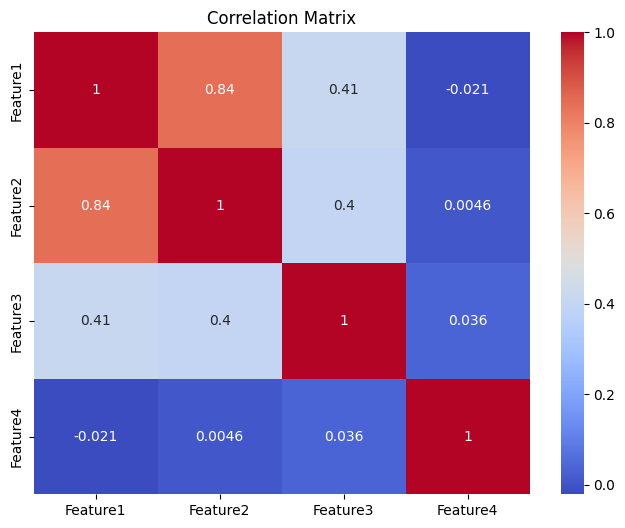

Strong Correlation Features: [('Feature1', 'Feature2'), ('Feature2', 'Feature1')]


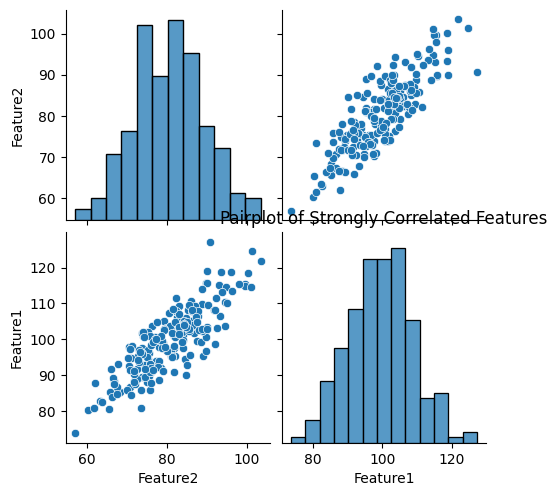

Moderately Correlated Features: [('Feature1', 'Feature3'), ('Feature2', 'Feature3'), ('Feature3', 'Feature1'), ('Feature3', 'Feature2')]


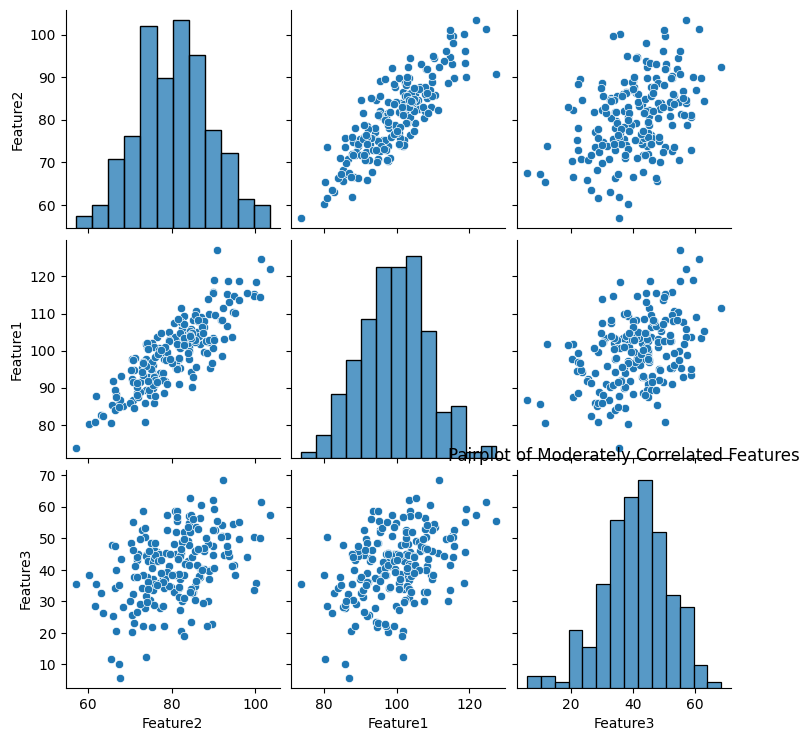

Weakly Correlated Features: [('Feature1', 'Feature4'), ('Feature2', 'Feature4'), ('Feature3', 'Feature4'), ('Feature4', 'Feature1'), ('Feature4', 'Feature2'), ('Feature4', 'Feature3')]


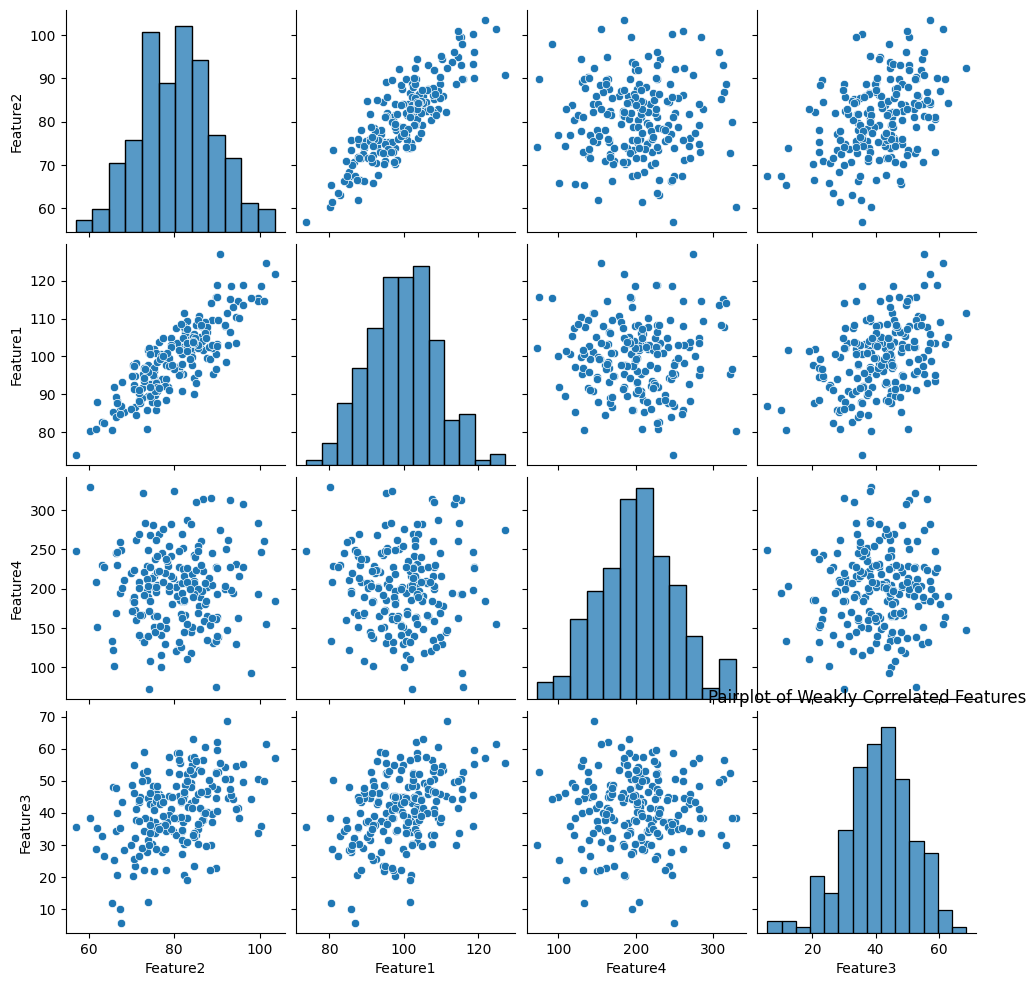

In [2]:

# 데이터 생성
np.random.seed(42)
df = pd.DataFrame({
    "Feature1": np.random.normal(100, 10, 200),
    "Feature2": np.random.normal(50, 5, 200),
    "Feature3": np.random.uniform(30, 70, 200),
    "Feature4": np.random.normal(200, 50, 200),
})

# Feature 간 상관관계 추가 (Feature1과 Feature2를 강한 상관관계로 만듦)
df["Feature2"] = df["Feature1"] * 0.8 + np.random.normal(0, 5, 200)  # 강한 상관관계

df["Feature3"] = df["Feature1"] * 0.4 + np.random.normal(0, 10, 200)  # 중간 상관관계

df["Feature4"] = np.random.normal(200, 50, 200)  # 약한 상관관계

# 상관계수 계산
correlation_matrix = df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Heatmap 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 상관계수 기준에 따라 Pairplot 생성
# 강한 상관관계 (|r| > 0.7)
strong_corr_features = [(f1, f2) for f1 in df.columns for f2 in df.columns if f1 != f2 and abs(correlation_matrix[f1][f2]) > 0.7]
if strong_corr_features:
    print("Strong Correlation Features:", strong_corr_features)
    sns.pairplot(df, vars=list(set([f for pair in strong_corr_features for f in pair])), kind="scatter")
    plt.title("Pairplot of Strongly Correlated Features")
    plt.show()

# 중간 정도의 상관관계 (0.3 < |r| <= 0.7)
moderate_corr_features = [(f1, f2) for f1 in df.columns for f2 in df.columns if f1 != f2 and 0.3 < abs(correlation_matrix[f1][f2]) <= 0.7]
if moderate_corr_features:
    print("Moderately Correlated Features:", moderate_corr_features)
    sns.pairplot(df, vars=list(set([f for pair in moderate_corr_features for f in pair])), kind="scatter")
    plt.title("Pairplot of Moderately Correlated Features")
    plt.show()

# 약한 상관관계 (|r| <= 0.3)
weak_corr_features = [(f1, f2) for f1 in df.columns for f2 in df.columns if f1 != f2 and abs(correlation_matrix[f1][f2]) <= 0.3]
if weak_corr_features:
    print("Weakly Correlated Features:", weak_corr_features)
    sns.pairplot(df, vars=list(set([f for pair in weak_corr_features for f in pair])), kind="scatter")
    plt.title("Pairplot of Weakly Correlated Features")
    plt.show()
